<a href="https://colab.research.google.com/github/ThangallapallyHasini/Lab-6.3/blob/main/2267_Ml_project_deekshitha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('/content/career_recommender.csv')
print(df.head())

  What is your name? What is your gender? What was your course in UG?  \
0        A.Uha Priya               Female                        B.Sc   
1              Aadil                 Male                         B.E   
2            Aakriti               Female                          BA   
3     Aanchal sharma               Female                         MBA   
4   Aangkeeta Sarkar               Female                      B.Tech   

  What is your UG specialization? Major Subject (Eg; Mathematics)  \
0                              Computer Applications                
1                       Computer Science Engineering                
2                                         Psychology                
3                                           Commerce                
4                        Instrumentation Engineering                

                            What are your interests?  \
0                                    Cloud computing   
1                                 

In [ ]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (1195, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 12 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                    --------------  ----- 
 0   What is your name?                                                                                                        1195 non-null   object
 1   What is your gender?                                                                                                      1195 non-null   object
 2   What was your course in UG?                                                                                               1195 non-null   object
 3   What is your UG specialization? Major Subject (Eg; Mathematics)                                                         

,What is your name?,What is your gender?,What was your course in UG?,What is your UG specialization? Major Subject (Eg; Mathematics),What are your interests?,What are your skills ? (Select multiple if necessary),What was the average CGPA or Percentage obtained in under graduation?,Did you do any certification courses additionally?,"If yes, please specify your certificate course title.",Are you working?,"If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.","Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)"
count,1195,1195,1195,1195,1195,1194,1195,1195,1194,1195,899,469
unique,1161,3,59,295,615,1007,301,3,523,2,483,236
top,Abhishek,Male,B.Tech,Computer Science Engineering,Technology,NO,76,Yes,No,Yes,Student (Unemployed),Masters in Business Administration
freq,3,806,488,174,132,44,56,611,580,713,116,42


In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
career_column_name = 'If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.               '
X = df.drop(career_column_name, axis=1)
y = df[career_column_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
print(df.columns.tolist())

['What is your name?', 'What is your gender?', 'What was your course in UG?', 'What is your UG specialization? Major Subject (Eg; Mathematics)', 'What are your interests?', 'What are your skills ? (Select multiple if necessary)', 'What was the average CGPA or Percentage obtained in under graduation?', 'Did you do any certification courses additionally?', 'If yes, please specify your certificate course title.', 'Are you working?', 'If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.               ', 'Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)']


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

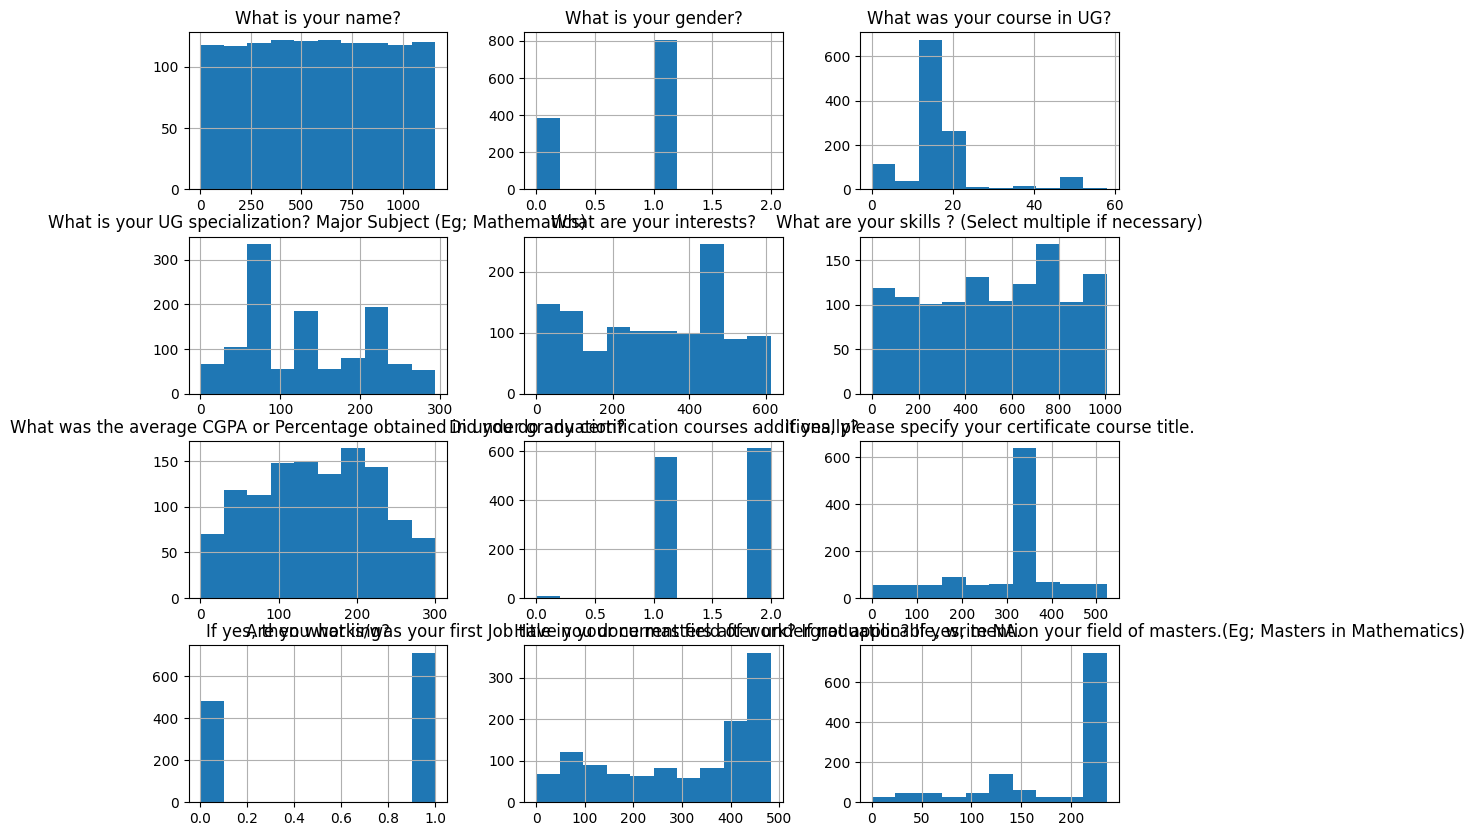

In [ ]:
df.hist(figsize=(12,10))
plt.show()

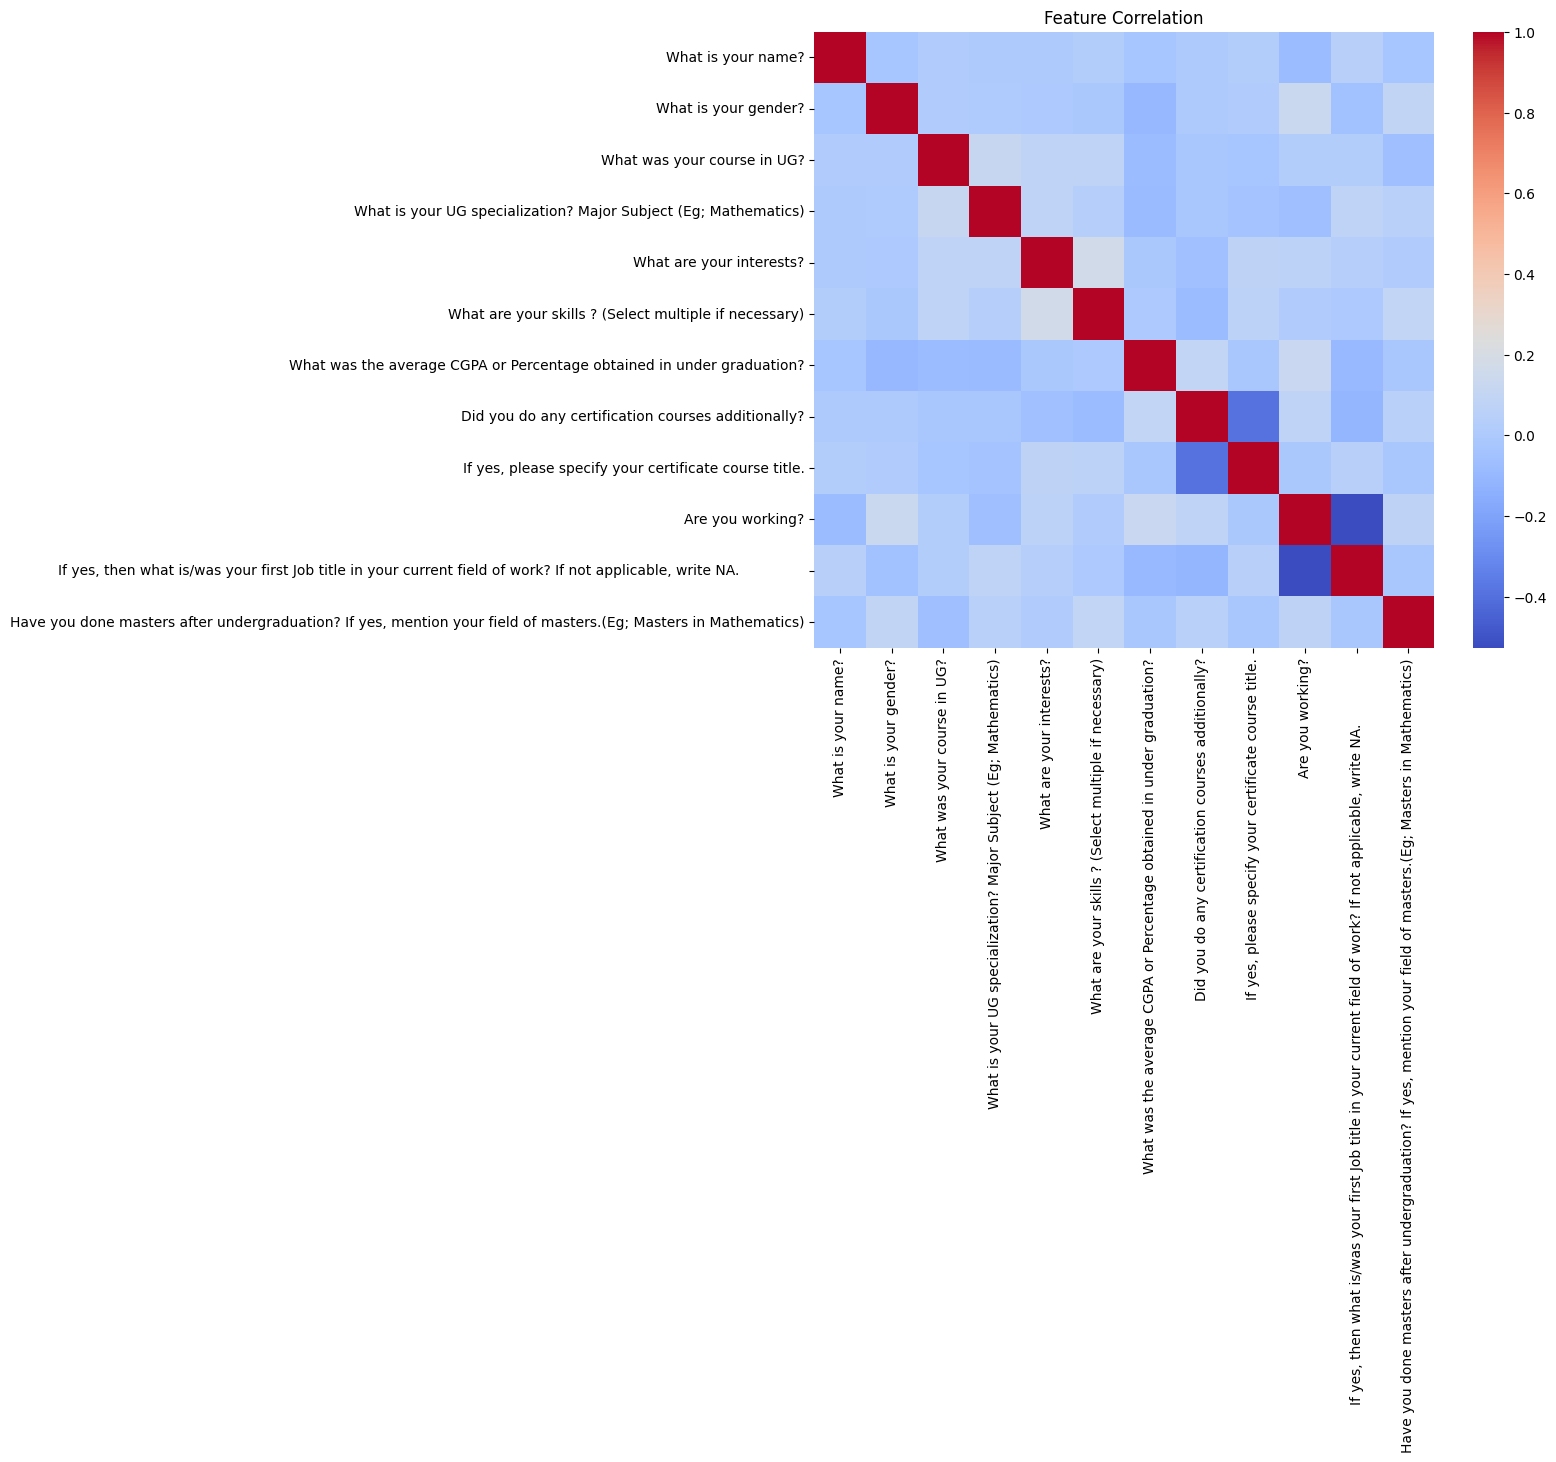

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")
plt.show()

In [ ]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

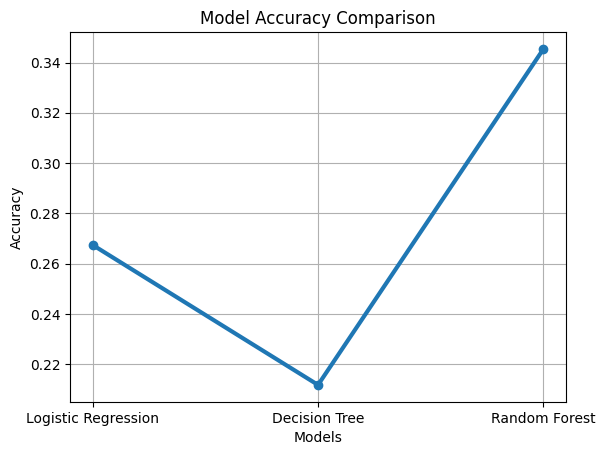

In [ ]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [acc_lr, acc_dt, acc_rf]

plt.plot(models, accuracy, marker='o', linewidth=3)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

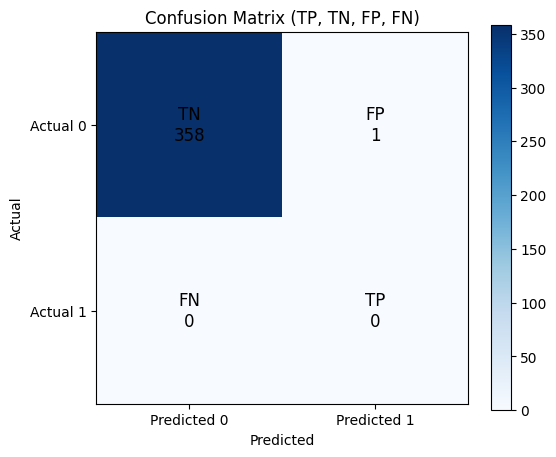

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Convert to binary (IMPORTANT if multi-class dataset)
y_test_bin = (y_test == 1).astype(int)
pred_bin = (pred_rf == 1).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test_bin, pred_bin)

# Extract values
TN, FP, FN, TP = cm.ravel()

# Plot
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')

# Add labels with values
labels = [["TN", "FP"], ["FN", "TP"]]

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{labels[i][j]}\n{cm[i][j]}",
                 ha='center', va='center', fontsize=12)

plt.xticks([0,1], ["Predicted 0", "Predicted 1"])
plt.yticks([0,1], ["Actual 0", "Actual 1"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (TP, TN, FP, FN)")

plt.colorbar()
plt.show()

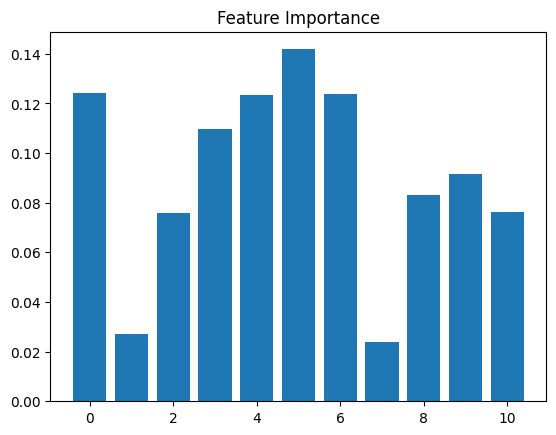

In [ ]:
importance = rf.feature_importances_

plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
sample = [X.iloc[0]]
prediction = rf.predict(sample)

print("Predicted Career:", prediction)

Predicted Career: [354]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Convert to binary (needed if multi-class dataset)
y_test_bin = (y_test == 1).astype(int)
pred_bin = (pred_rf == 1).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test_bin, pred_bin)
precision = precision_score(y_test_bin, pred_bin)
recall = recall_score(y_test_bin, pred_bin)
f1 = f1_score(y_test_bin, pred_bin)

# Print results
print("Accuracy :", accuracy)

Accuracy : 0.9972144846796658


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
